In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/livebench.csv')

In [4]:
data.head()

,model,version_date,task,score,category,organization
0,amazon.nova-lite-v1:0,2024-11-25,AMPS_Hard,50.0,Mathematics,Amazon
1,amazon.nova-micro-v1:0,2024-11-25,AMPS_Hard,48.0,Mathematics,Amazon
2,amazon.nova-pro-v1:0,2024-11-25,AMPS_Hard,45.0,Mathematics,Amazon
3,chatgpt-4o-latest-2025-01-29,2024-11-25,AMPS_Hard,54.0,Mathematics,OpenAI
4,claude-3-5-haiku-20241022,2024-11-25,AMPS_Hard,42.0,Mathematics,Anthropic


In [5]:
data.size

87120

In [6]:
data.shape

(14520, 6)

In [7]:
data.columns

Index(['model', 'version_date', 'task', 'score', 'category', 'organization'], dtype='object')

In [8]:
data.isna()

,model,version_date,task,score,category,organization
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
14515,False,False,False,False,False,False
14516,False,False,False,False,False,False
14517,False,False,False,False,False,False
14518,False,False,False,False,False,False


In [9]:
data.isna().sum()

model           0
version_date    0
task            0
score           4
category        0
organization    0
dtype: int64

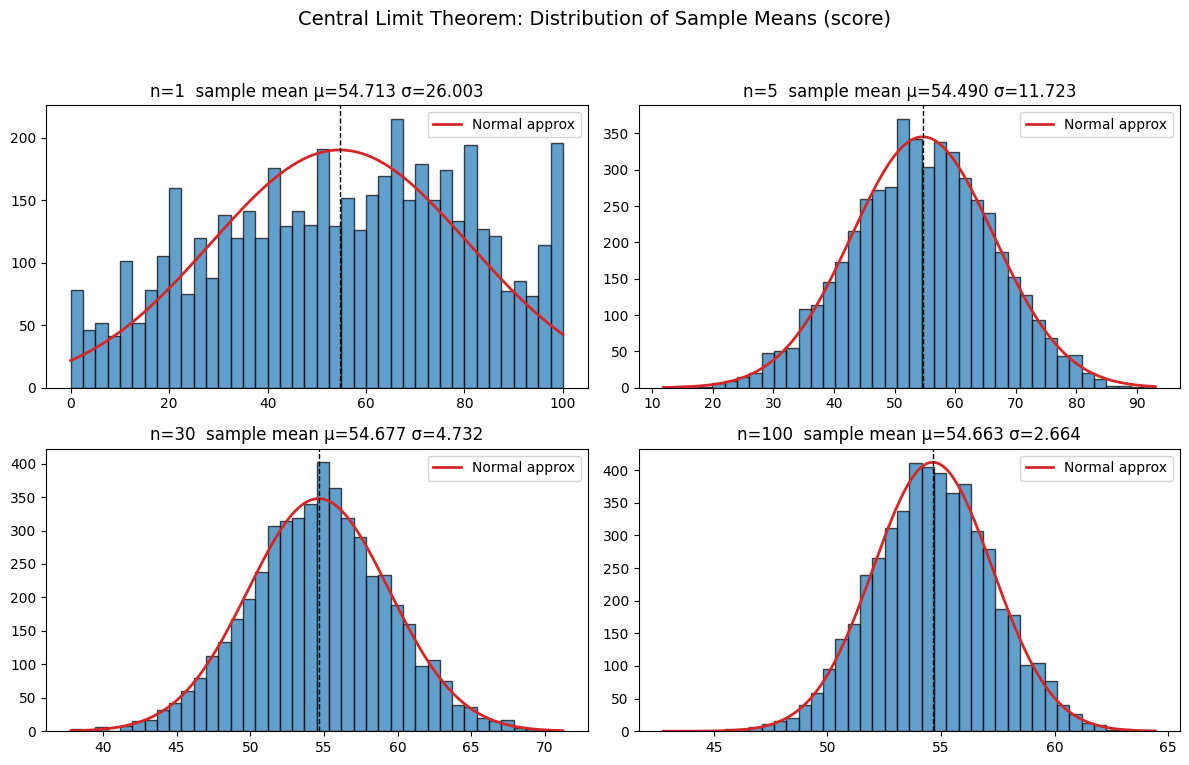

In [10]:
# CLT demonstration: sample means and histograms for different sample sizes
scores = data['score'].dropna().values
pop_mean = np.mean(scores)
pop_std = np.std(scores, ddof=0)

sample_sizes = [1, 5, 30, 100]
num_samples = 5000

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, n in zip(axes, sample_sizes):
    # draw sample means
    means = [np.mean(np.random.choice(scores, size=n, replace=True)) for _ in range(num_samples)]
    counts, bins, _ = ax.hist(means, bins=40, alpha=0.7, color='C0', edgecolor='black')
    bin_width = bins[1] - bins[0]
    # normal curve using CLT: mean = pop_mean, std = pop_std / sqrt(n)
    sigma = pop_std / np.sqrt(n)
    x = np.linspace(min(bins), max(bins), 200)
    normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - pop_mean) / sigma) ** 2)
    ax.plot(x, normal_pdf * len(means) * bin_width, color='C3', lw=2, label='Normal approx')
    ax.axvline(pop_mean, color='k', linestyle='--', lw=1)
    ax.set_title(f"n={n}  sample mean μ={np.mean(means):.3f} σ={np.std(means, ddof=1):.3f}")
    ax.legend()

plt.suptitle("Central Limit Theorem: Distribution of Sample Means (score)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('clt_histograms.png', dpi=150)
plt.show()